In [5]:
import h5py
import numpy as np    
import matplotlib.pyplot as plt
import os
import argparse
import tqdm
from matplotlib.animation import FuncAnimation, PillowWriter
%matplotlib widget

datafolder = '/travail/xgong/new_simu_highppc/output/mi25-MA40-PPC300'
# datafolder = "/travail/xgong/test_separate/output/mi25-MA40"
datafolder = "/travail/xgong/test_mpi/output/mi25-MA40_removeweight"
# datafolder = "/travail/xgong/test_mpi/output/mi25-MA40_2"
plt.rcParams.update({
    # "text.usetex": True,
    "font.family": 'STIXGeneral',
    "text.latex.preamble": r"\usepackage{lmodern}",
    'mathtext.fontset': 'cm'
})

os.system('ls '+ os.path.join(datafolder, 'fields/*h5') + ' > ' + os.path.join(datafolder, 'filelist_flds.txt'))
with open(os.path.join(datafolder, 'filelist_flds.txt')) as f:
    files = f.readlines()
    for i in range(len(files)):
        files[i] = files[i].strip()
print(len(files))
fs = 15
fstick = 12


import scipy.ndimage.filters as filters

def smooth( x, window_len=61, window='hanning'):
    return filters.convolve1d(x, np.ones(window_len)/window_len)


245


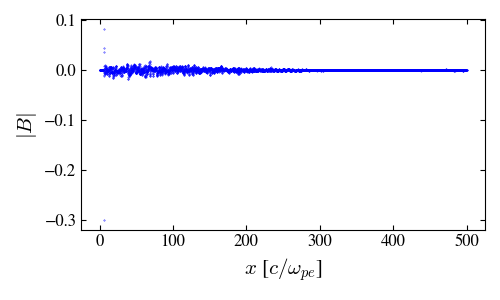

In [9]:
x =-2

file = h5py.File(files[x],'r+')['Step0']
x1 = (np.array(file['X1']))
idx = np.where((x1 > 0) & (x1 < 2000))[0]
x1 = x1[idx]
Exmean = np.array(file['fAvgEx'])[idx]/10
B3mean = np.array(file['fAvgBz'])[idx]/10
E2mean = np.array(file['fAvgEy'])[idx]/10
Exjpt = np.array(file['fJptEx'])[idx]#/25
J1 = (np.array(file['fJ1']))[idx]
J2 = (np.array(file['fJ2']))[idx]
J3 = (np.array(file['fJ3']))[idx]
B1 = (np.array(file['fB1']))[idx]
B2 = (np.array(file['fB2']))[idx]
B3 = (np.array(file['fB3']))[idx]
E1 = (np.array(file['fE1']))[idx]
E2 = (np.array(file['fE2']))[idx]
E3 = (np.array(file['fE3']))[idx]
J2 = smooth(np.array(file['fJ2']), window_len=4)[idx]
N1 = smooth(np.array(file['fN_1']))[idx]
N2 = smooth(np.array(file['fN_2']))[idx]

uExB = (E2mean/B3mean)
plt.figure(figsize = (5,3))
# plt.scatter(x1, smooth(N1,window_len=50)-smooth(N2,window_len=50) , color = 'red', s = 0.1)
plt.scatter(x1, E1, color = 'blue', s = 0.1)
# plt.ylim(-0.01,0.01)
plt.ylabel(r"$|B|$ ", fontsize = 15)
# plt.ylabel(r"$N$", fontsize = 15)
plt.xlabel(r'$x$ [$c / \omega_{pe}$]', fontsize= 15)
plt.tight_layout()
plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# plt.savefig("./plots/Bmean.png", dpi=500, bbox_size='tight')


nan


/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in true_divide
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/ipykernel_launcher.py:32: RuntimeWarning: Mean of empty slice.
/mesopsl3/home/xgong/.venv/lib64/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


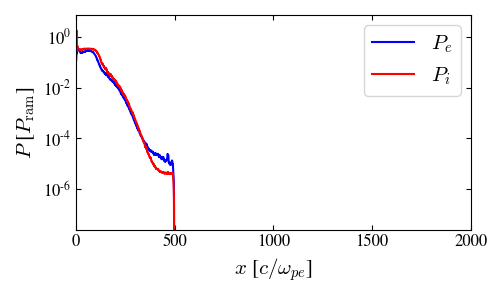

Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}
Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}


In [7]:
x =-2

mr =25

file = h5py.File(files[x],'r+')['Step0']
T11_e = np.array(file['fT11_1'])
T22_e = np.array(file['fT22_1'])
T11_i = np.array(file['fT11_2'])
# print(file.keys())
T22_i = np.array(file['fT22_2'])
x1 = np.array(file['X1'])

plt.figure(figsize = (5,3))
plt.plot(x1, smooth(T22_e / T11_i[-300:-200].mean()) ,markersize = 0.01,linestyle='-', color = 'blue', label=r'$P_e$')
plt.plot(x1, smooth(T22_i / T11_i[-300:-200].mean()),markersize = 0.01,linestyle='-', color = 'red', label=r'$P_i$')
# plt.plot(x1, smooth(T22_i / T22_i[-600:-500].mean()/2),markersize = 0.01,linestyle='-', color = 'red', label=r'$P_i$')
# plt.scatter(x1, smooth(T11_e) ,s = 0.01, color = 'blue')
# plt.scatter(x1, smooth(T22_e /mr**2)/smooth(T22_i ) ,s = 0.01, color = 'blue')

plt.legend(fontsize=15)
# plt.scatter(x1, smooth(T11_i*mr**2),s = 0.01, color = 'red')
# plt.ylim(1e-7,0.6)
plt.xlim(0,2000)
plt.yscale('log')

plt.xlabel(r"$x$ [$c / \omega_{pe}$]", fontsize=15)
plt.ylabel(r"$P$ [$P_\mathrm{ram}$]", fontsize=15)
plt.tight_layout()
plt.tick_params(which='minor', direction='in', length=3, width=0.5, colors='k', grid_color='r', grid_alpha=0.5, labelsize=fstick)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=fstick)
# plt.savefig('./plots/TemperatureRatio.png',dpi=500, bbox_size='tight')
print((T22_e / T22_i / mr**2)[16000:17000].mean())


Text(0.5, 0, 'X [$c / \\omega_e$]')

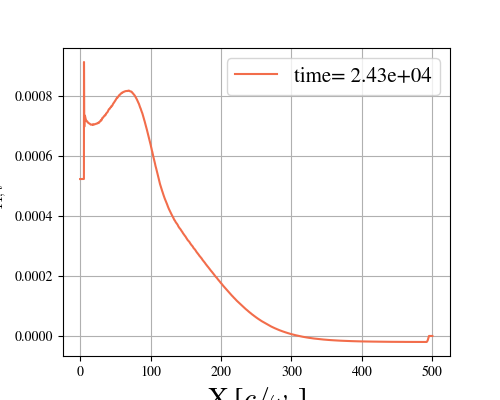

Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}
Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}
Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}
Unhandled message type set_device_pixel_ratio. {'device_pixel_ratio': 1.5, 'type': 'set_device_pixel_ratio'}


In [8]:
x = [-2]
colormap = plt.get_cmap('OrRd')
colors = colormap(np.linspace(0.6,1,len(x)))
plt.figure(figsize=(5,4))
mi=25

for i in range(len(x)):
    file = h5py.File(files[x[i]],'r+')['Step0']
    T11_i = np.array(file['fT11_2'])
    Exmean = np.array(file['fAvgEx'])/10
    Exjpt = np.array(file['fJptEx'])#/25
    Ex = np.array(file['fE1'])
    x1 = np.array(file['X1'])
    t_sim = np.array(file['Time'])
    def integrate(x,y):
        return ((y[1:]+ y[:-1])/2*(x[1:] - x[:-1])).sum()

    def stepintegrate(x,y):
        res = np.zeros_like(y)
        res = (np.cumsum(y[::-1]) * (x[1]-x[0]))[::-1]
        return res


    plt.plot(x1, stepintegrate(x1, Exmean)/T11_i[-2500]/ mi**2, color = colors[i],label='time= %.2e'%(t_sim))
    # plt.plot(x1, stepintegrate(x1, Ex))
    plt.grid()

plt.legend(fontsize =15)
plt.ylabel(r'$\frac{\int_x^\infty E(x) dx} { T_{11,i}}$', fontsize= 20)
plt.xlabel(r'X [$c / \omega_e$]', fontsize= 20)
# plt.yscale('log')
# plt.ylim(1e-5,6)
# plt.xlim(000,5000)